# 📘 Day 19: Classification Fundamentals (Part 2)
## Confusion Matrix, Accuracy, Precision, Recall, F1-score, ROC Curve, AUC, Threshold Tuning

This notebook contains **heavy theory + hands-on practice** aligned with real-world ML applications.


# 🔷 1. Confusion Matrix (Deep Theory)

A Confusion Matrix is the **foundation of classification evaluation**. It helps us understand not just *how many predictions were correct*, but **what type of errors the model is making**.

### Structure:
|                | Predicted Positive | Predicted Negative |
|----------------|-------------------|-------------------|
| Actual Positive| True Positive (TP)| False Negative (FN)|
| Actual Negative| False Positive (FP)| True Negative (TN)|

### Deep Interpretation:
- **TP** → Model correctly identifies positive class
- **TN** → Model correctly identifies negative class
- **FP** → Model falsely predicts positive (Type 1 Error)
- **FN** → Model misses a positive case (Type 2 Error)

### Industry Insight:
- Fraud Detection → FN is dangerous (missed fraud)
- Medical Diagnosis → FN is dangerous (missed disease)
- Spam Detection → FP is dangerous (blocking important mail)

👉 Confusion matrix helps you align model performance with **business cost**.


In [4]:

from sklearn.metrics import confusion_matrix
import numpy as np

y_true = [1,0,1,1,0,1,0,0,1,0]
y_pred = [1,0,1,0,1,1,1,0,1,0]

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[3 2]
 [1 4]]



# 🔷 2. Accuracy (Limitations Explained)

Accuracy measures overall correctness.

### Formula:
Accuracy = (TP + TN) / Total Predictions

### Problem:
Accuracy fails when dataset is **imbalanced**.

### Example:
If fraud is only 1%, predicting "No Fraud" always:
👉 Accuracy = 99% (but model is useless)

### Key Insight:
Accuracy should **never be used alone** in real-world ML.


In [5]:

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_true, y_pred))


Accuracy: 0.7



# 🔷 3. Precision & Recall (Core Trade-off)

## Precision
Precision = TP / (TP + FP)

👉 Out of predicted positives, how many are correct?

Use when **false positives are costly**

---

## Recall
Recall = TP / (TP + FN)

👉 Out of actual positives, how many did we catch?

Use when **missing positives is dangerous**

---

## Key Trade-off:
- Increasing Precision → decreases Recall
- Increasing Recall → decreases Precision

👉 This trade-off is controlled using **threshold tuning**


In [6]:

from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))


Precision: 0.6666666666666666
Recall: 0.8



# 🔷 4. F1 Score (Balanced Metric)

F1 Score = Harmonic Mean of Precision and Recall

F1 = 2 * (Precision * Recall) / (Precision + Recall)

### Why Harmonic Mean?
Because it penalizes extreme values.

### When to use:
- Imbalanced datasets
- Need balance between Precision & Recall


In [7]:

from sklearn.metrics import f1_score
print("F1 Score:", f1_score(y_true, y_pred))


F1 Score: 0.7272727272727273



# 🔷 5. ROC Curve (Threshold Independent Evaluation)

ROC Curve plots:
- X-axis → False Positive Rate (FPR)
- Y-axis → True Positive Rate (Recall)

FPR = FP / (FP + TN)

### Key Insight:
ROC shows model performance **across all thresholds**

### Diagonal Line:
Represents random guessing

Better model → curve closer to top-left


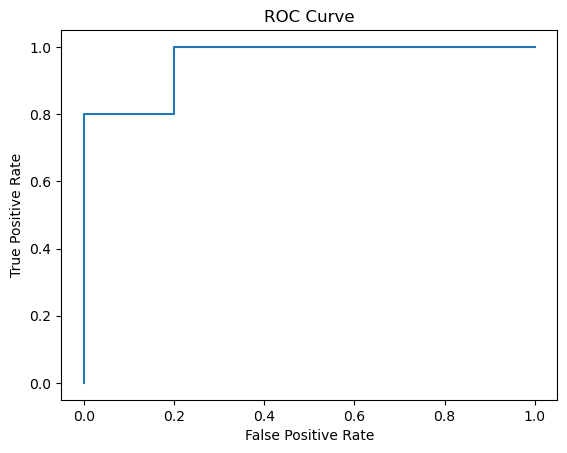

In [8]:

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

probs = np.array([0.9,0.1,0.8,0.4,0.3,0.7,0.6,0.2,0.85,0.05])

fpr, tpr, thresholds = roc_curve(y_true, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()



# 🔷 6. AUC (Area Under Curve)

AUC represents the **overall performance of the model**

### Interpretation:
- 1.0 → Perfect
- 0.9 → Excellent
- 0.8 → Good
- 0.5 → Random

### Intuition:
Probability that model ranks a random positive higher than a random negative


In [9]:

from sklearn.metrics import roc_auc_score
print("AUC Score:", roc_auc_score(y_true, probs))


AUC Score: 0.9600000000000001



# 🔷 7. Threshold vs Precision & Recall

Default threshold = 0.5

### Lower Threshold:
- More positives predicted
- Recall ↑
- Precision ↓

### Higher Threshold:
- Fewer positives predicted
- Precision ↑
- Recall ↓

👉 Threshold tuning is **critical in production systems**


In [10]:

threshold = 0.5
custom_pred = (probs >= threshold).astype(int)

print("Custom Predictions:", custom_pred)


Custom Predictions: [1 0 1 0 0 1 1 0 1 0]



# 🧪 Mini Project: Fraud Detection Simulation

Goal:
- Observe how metrics change with threshold

Tasks:
1. Change threshold
2. Compute Precision & Recall
3. Analyze trade-off


In [11]:

for t in [0.3, 0.5, 0.7]:
    preds = (probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print("Precision:", precision_score(y_true, preds))
    print("Recall:", recall_score(y_true, preds))



Threshold: 0.3
Precision: 0.7142857142857143
Recall: 1.0

Threshold: 0.5
Precision: 0.8
Recall: 0.8

Threshold: 0.7
Precision: 1.0
Recall: 0.8
